In [ ]:
!pip install PyWavelets -q

In [ ]:
import re
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss
from scipy.stats import skew, kurtosis, iqr
from scipy.signal import welch
from sklearn.model_selection import learning_curve
import pywt

## Importar Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_json("/content/drive/MyDrive/Datasets/Earthquakes_seismic/Earthquakes_seismic.ndjson", lines=True)
df.head(100)

,rel_filepath,dt,npts,mag,type,vs,data
0,1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN101...,0.010,27011,Mag. 4-6,SS,Vs30. 0-200,"[5e-10, 5e-10, 5e-10, 5e-10, 5e-10, 5e-10, 5e-..."
1,1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN101...,0.010,27011,Mag. 4-6,SS,Vs30. 0-200,"[-1.9e-09, -1.9e-09, -1.9e-09, -1.9e-09, -1.9e..."
2,1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN101...,0.010,27011,Mag. 4-6,SS,Vs30. 0-200,"[5e-10, 5e-10, 5e-10, 5e-10, 5e-10, 5e-10, 5e-..."
3,1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN103...,0.010,19086,Mag. 4-6,SS,Vs30. 0-200,"[8.3e-09, 8.4e-09, 8.4e-09, 8.5e-09, 8.6000000..."
4,1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN103...,0.010,19086,Mag. 4-6,SS,Vs30. 0-200,"[1e-10, 1e-10, 1e-10, 1e-10, 1e-10, 1e-10, -1e..."
...,...,...,...,...,...,...,...
95,1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN317...,0.005,5751,Mag. 4-6,SS,Vs30. 0-200,"[0.0003800804, 0.00037902840000000003, 0.00037..."
96,1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN319...,0.005,13000,Mag. 4-6,SS,Vs30. 0-200,"[0.0002735327, 0.0002950585, 0.0002912449, 0.0..."
97,1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN319...,0.005,13000,Mag. 4-6,SS,Vs30. 0-200,"[-0.0007082216000000001, -0.0007009732, -0.000..."
98,1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN319...,0.005,13000,Mag. 4-6,SS,Vs30. 0-200,"[-0.0007622356, -0.0007615492, -0.000765880700..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10587 entries, 0 to 10586
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rel_filepath  10587 non-null  object 
 1   dt            10587 non-null  float64
 2   npts          10587 non-null  int64  
 3   mag           10587 non-null  object 
 4   type          10587 non-null  object 
 5   vs            10587 non-null  object 
 6   data          10587 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 579.1+ KB


In [ ]:
# Revisar que data es una lista
print(type(df["data"][0]))

<class 'list'>


In [ ]:
# Obtener el id del Evento
def extract_event(path):
    match = re.search(r'RSN\d+', path)
    return match.group(0) if match else None

df["event_id"] = df["rel_filepath"].apply(extract_event)

print(df[["rel_filepath", "event_id"]].head(10))

                                        rel_filepath  event_id
0  1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN101...  RSN10199
1  1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN101...  RSN10199
2  1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN101...  RSN10199
3  1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN103...  RSN10318
4  1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN103...  RSN10318
5  1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN103...  RSN10318
6  1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN103...  RSN10341
7  1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN103...  RSN10341
8  1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN103...  RSN10341
9  1 Stiker Slip (SS)/Mag. 4-6/Vs30. 0-200/RSN113...  RSN11332


In [ ]:
# Desvalance de clases
print(df["event_id"].nunique())
print(df["type"].value_counts())

1781
type
RO    4224
SS    3877
NO    2486
Name: count, dtype: int64


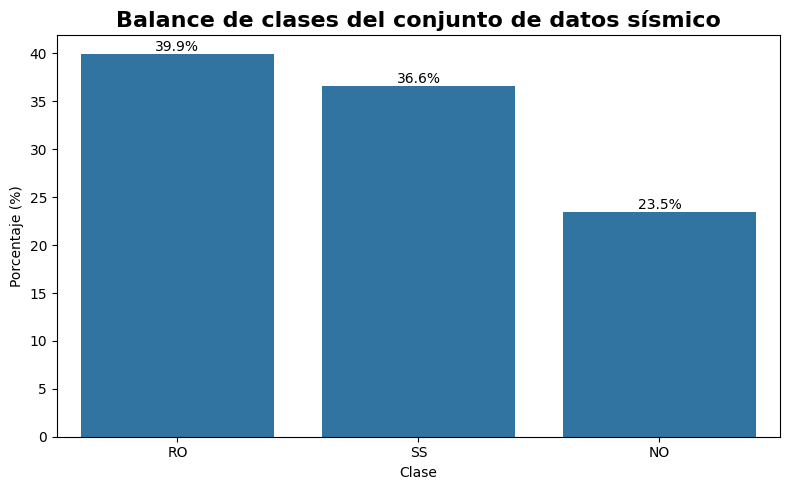

In [ ]:
porcentaje = (
    df["type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

porcentaje.columns = ["Tipo", "Porcentaje"]

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=porcentaje,
    x="Tipo",
    y="Porcentaje"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title(
    "Balance de clases del conjunto de datos sísmico",
    fontsize=16,
    weight="bold"
)
plt.xlabel("Clase")
plt.ylabel("Porcentaje (%)")

plt.tight_layout()
plt.show()

In [ ]:
# Eventos únicos
event_labels = (
    df.groupby("event_id")["type"]
      .first()
      .reset_index()
)


In [ ]:
train_val_events, test_events = train_test_split(
    event_labels,
    test_size=0.2,
    stratify=event_labels["type"],
    random_state=42
)

train_events, val_events = train_test_split(
    train_val_events,
    test_size=0.25,
    stratify=train_val_events["type"],
    random_state=42
)

In [ ]:
train_df = df[
    df["event_id"].isin(train_events["event_id"])
]

val_df = df[
    df["event_id"].isin(val_events["event_id"])
]

test_df = df[
    df["event_id"].isin(test_events["event_id"])
]

In [ ]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(6329, 8)
(2126, 8)
(2132, 8)


In [ ]:
# Verificar NO leakage
print(set(train_df.event_id) & set(val_df.event_id))
print(set(train_df.event_id) & set(test_df.event_id))
print(set(val_df.event_id) & set(test_df.event_id))

set()
set()
set()


## Feature Extractión

In [ ]:
# Tiempo de las muestras
print(df["dt"].describe())

count    10587.000000
mean         0.006852
std          0.003618
min          0.001400
25%          0.005000
50%          0.005000
75%          0.010000
max          0.020000
Name: dt, dtype: float64


In [ ]:
print(df["dt"].nunique())

17


In [ ]:
print("Número de registros:", len(df))

print("\nClases:")
print(df["type"].value_counts())

print("\nMagnitudes:")
print(df["mag"].value_counts().head())

print("\nVs:")
print(df["vs"].value_counts().head())

Número de registros: 10587

Clases:
type
RO    4224
SS    3877
NO    2486
Name: count, dtype: int64

Magnitudes:
mag
Mag. 4-6    5756
Mag. 6-8    4831
Name: count, dtype: int64

Vs:
vs
Vs30. 400-600    3262
Vs30. 200-400    2972
Vs30. 600-       2888
Vs30. 0-200      1465
Name: count, dtype: int64


In [ ]:
# Longitud de señales
signal_lengths = df["data"].apply(len)

signal_lengths.describe()

,data
count,10587.000000
mean,10570.010012
std,8155.872309
min,300.000000
25%,4700.000000
50%,8000.000000
75%,14399.500000
max,65500.000000


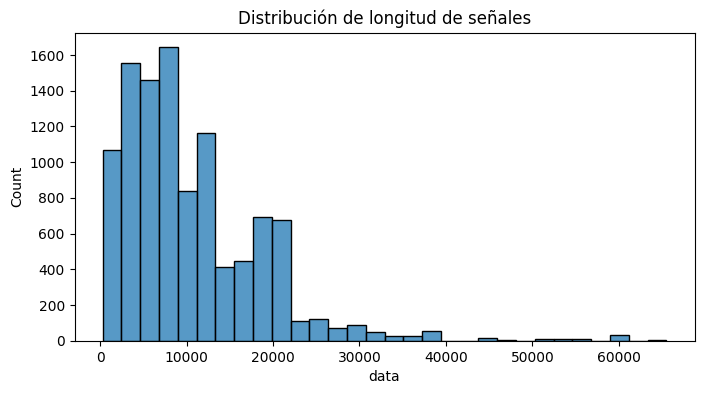

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(
    signal_lengths,
    bins=30
)

plt.title("Distribución de longitud de señales")
plt.show()

In [ ]:
# Revisar señales vacias
df["data"].apply(len).eq(0).sum()

np.int64(0)

In [ ]:
# Señales nulas
def count_nan(signal):
    return np.isnan(signal).sum()

df["nan_count"] = df["data"].apply(count_nan)

In [ ]:
df["nan_count"].sum()

np.int64(0)

In [ ]:
# Revisar Amplitudes
max_amp = df["data"].apply(
    lambda x: np.max(np.abs(x))
)

max_amp.describe()

,data
count,10587.000000
mean,0.085391
std,0.130551
min,0.000001
25%,0.012893
50%,0.042099
75%,0.102655
max,2.280821


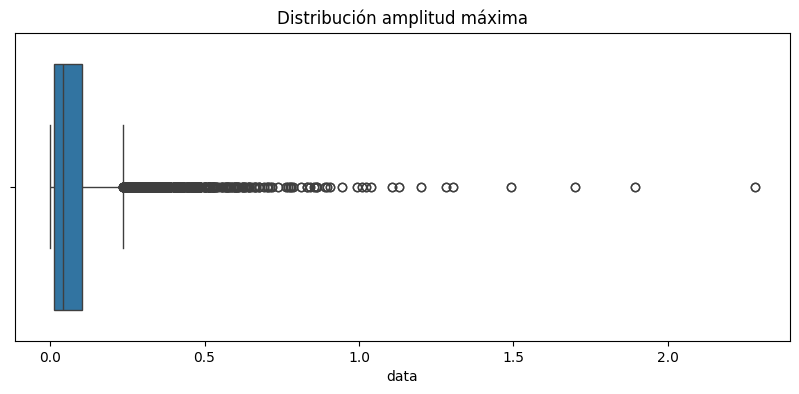

In [ ]:
# Amplitud Maxima
plt.figure(figsize=(10,4))

sns.boxplot(
    x=max_amp
)

plt.title(
    "Distribución amplitud máxima"
)

plt.show()

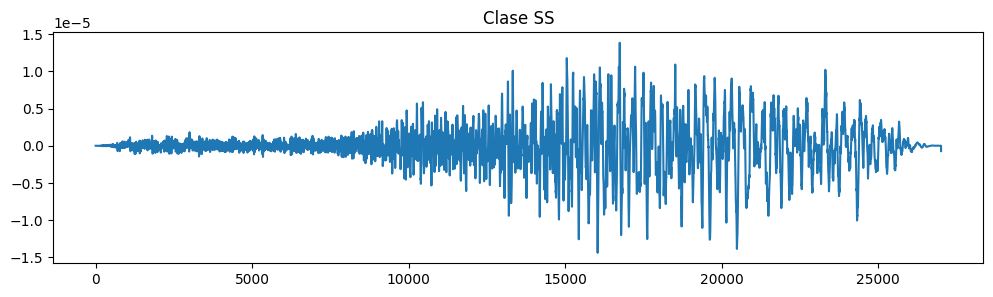

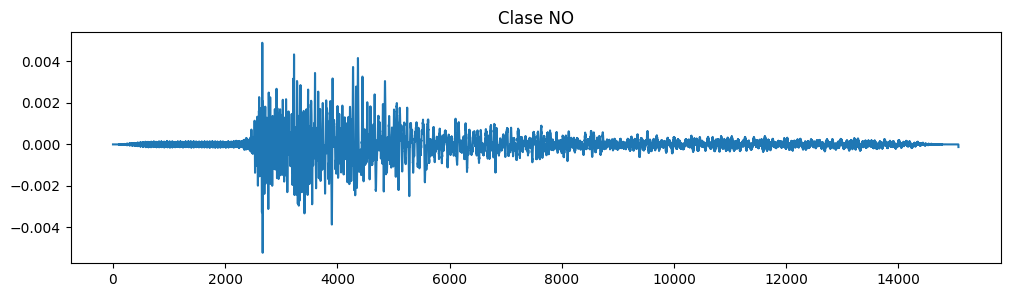

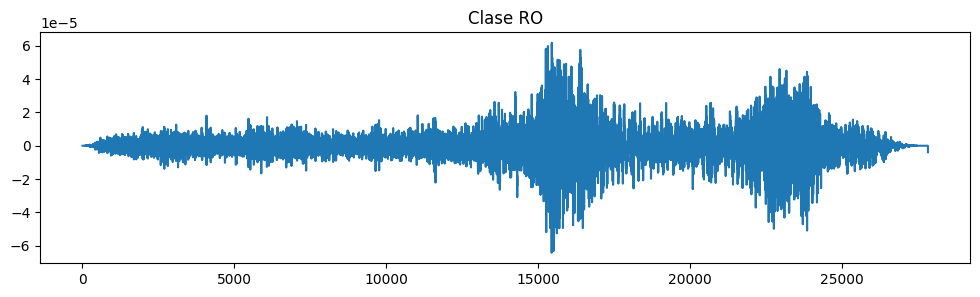

In [ ]:
# Graficar Señales
classes = df["type"].unique()

for c in classes:

    sample = df[
        df["type"] == c
    ].iloc[0]

    plt.figure(figsize=(12,3))

    plt.plot(sample["data"])

    plt.title(
        f"Clase {c}"
    )

    plt.show()

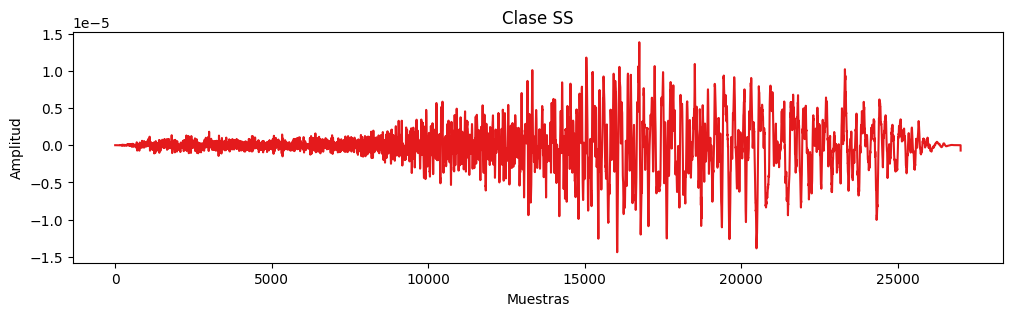

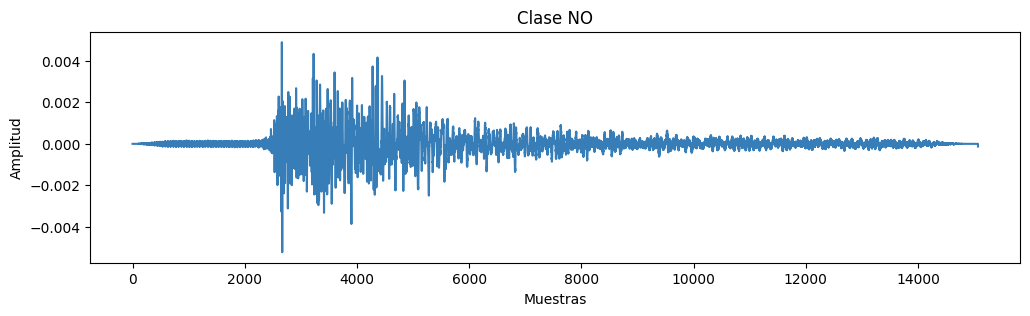

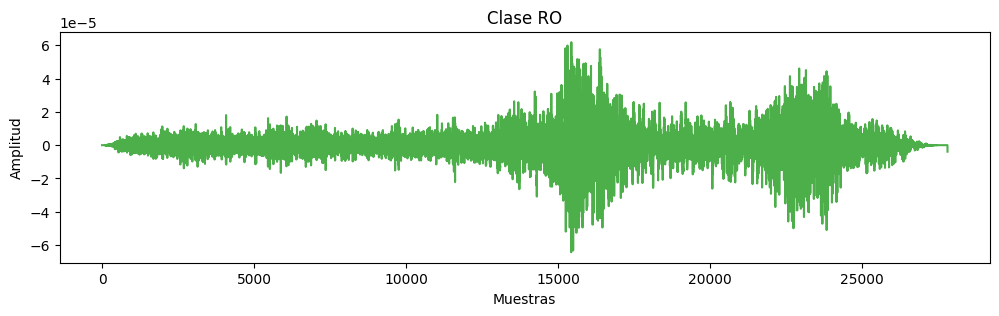

In [ ]:
import matplotlib.pyplot as plt

classes = df["type"].unique()
colors = plt.cm.Set1(range(len(classes)))

for i, c in enumerate(classes):

    sample = df[df["type"] == c].iloc[0]

    plt.figure(figsize=(12,3))

    plt.plot(
        sample["data"],
        color=colors[i],
        linewidth=1.5
    )

    plt.title(f"Clase {c}")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")

    plt.show()

In [ ]:
def extract_features(signal, dt):

    signal = np.asarray(signal)


    def band_energy(freqs, fft_mag, low, high):

      mask = (
          (freqs >= low) &
          (freqs < high)
      )

      return np.sum(
          fft_mag[mask]**2
      )

    # Normalización / Para aprender forma y no amplitud

    std = np.std(signal)

    if std > 1e-12:
        signal = (
            signal - np.mean(signal)
        ) / std

    feats = {}

    # Estadísticas

    feats["mean"] = np.mean(signal) # Promedio de la señal -> ¿La señal está centrada en cero o tiene un desplazamiento?
    feats["std"] = std # Desviación estándar -> Que tan dispersa es la señal
    feats["var"] = np.var(signal) # Varianza.

    feats["min"] = np.min(signal) # Pico más bajo
    feats["max"] = np.max(signal) # Pico más alto

    feats["median"] = np.median(signal) #Valor central -> Más robusto que la media frente a ruido

    feats["iqr"] = iqr(signal) # Rango intercuartílico -> Mide dispersión P75 - P25

    # Asimetría.
    # 0 → simétrica
    # 0 + → cola derecha
    # - 0 → cola izquierda
    feats["skew"] = skew(signal)

    feats["kurtosis"] = kurtosis(signal) # Mide cuántos picos extremos tiene

    #Desviación absoluta media
    feats["mad"] = np.mean(
        np.abs(signal - np.mean(signal))
    )

    # Percentiles
    feats["p05"] = np.percentile(signal, 5)
    feats["p25"] = np.percentile(signal, 25)
    feats["p75"] = np.percentile(signal, 75)
    feats["p95"] = np.percentile(signal, 95)

    # Energía

    feats["energy"] = np.sum(signal**2) # ¿Cuánta energía total tiene la señal?

    feats["rms"] = np.sqrt( #Amplitud efectiva -> Muy usada en vibraciones
        np.mean(signal**2)
    )

    # Amplitud

    peak = np.max(np.abs(signal)) # Máximo valor absoluto

    feats["peak"] = peak

    feats["peak_to_peak"] = np.ptp(signal) # Distancia entre extremos -> max - min

    # ¿La energía está distribuida o concentrada en pocos picos?
    # Valores altos indican impulsos fuertes.
    feats["crest_factor"] = (
        peak /
        (feats["rms"] + 1e-10)
    )

    # Duración
    feats["duration"] = (
        len(signal) * dt
    )

    # ZCR Zero Crossing Rate
    # Número de veces que cruza cero.
    feats["zcr"] = np.mean(
        np.abs(
            np.diff(
                np.signbit(signal)
            )
        )
    )

    # FFT -> Tiempo → Frecuencia
    signal_centered = (
        signal -
        np.mean(signal)
    )

    freqs = np.fft.rfftfreq(
        len(signal),
        d=dt
    )

    fft_mag = np.abs(
        np.fft.rfft(signal_centered)
    )

    #Energia entre
    feats["band_0_5"] = band_energy(
        freqs,
        fft_mag,
        0,
        5
    )

    feats["band_5_10"] = band_energy(
        freqs,
        fft_mag,
        5,
        10
    )

    feats["band_10_20"] = band_energy(
        freqs,
        fft_mag,
        10,
        20
    )

    feats["band_20_40"] = band_energy(
        freqs,
        fft_mag,
        20,
        40
    )

    feats["band_40_plus"] = band_energy(
        freqs,
        fft_mag,
        40,
        freqs.max()
    )

    #Frecuencia dominante -> ¿Dónde está el pico principal del espectro?
    dominant_idx = (
        np.argmax(
            fft_mag[1:]
        ) + 1
    )

    feats["dominant_freq"] = (
        freqs[dominant_idx]
    )

    # Centro de gravedad espectral -> ¿La energía está más en bajas o altas frecuencias?
    feats["spectral_centroid"] = (
        np.sum(freqs * fft_mag)
        /
        (np.sum(fft_mag)+1e-10)
    )

    # Anchura espectra -> ¿La energía está concentrada o dispersa?
    centroid = (
        feats["spectral_centroid"]
    )

    feats["spectral_bandwidth"] = (
        np.sqrt(
            np.sum(
                ((freqs-centroid)**2)
                * fft_mag
            )
            /
            (np.sum(fft_mag)+1e-10)
        )
    )

    # Entropía espectral -> ¿La señal es ordenada o caótica? -> Muy útil para distinguir ruido
    p = fft_mag / (
        np.sum(fft_mag)+1e-10
    )

    feats["spectral_entropy"] = (
        -np.sum(
            p*np.log2(
                p+1e-10
            )
        )
    )

    # PSD (Densidad Espectral de Potencia)

    fs = 1 / dt

    f_psd, psd = welch(
        signal,
        fs=fs,
        nperseg=min(
            1024,
            len(signal)
        )
    )

    feats["psd_mean"] = np.mean(psd) # Potencia promedio.

    feats["psd_std"] = np.std(psd) # Variabilidad de la potencia.

    feats["psd_max"] = np.max(psd) # Pico máximo de potencia.

    # Frecuencia con mayor potencia.
    feats["dominant_psd_freq"] = (
        f_psd[np.argmax(psd)]
    )

    # Arias -> Mide energía acumulada del movimiento
    feats["arias"] = (
        np.sum(signal**2)
        * dt
    )

    # CAV -> Cumulative Absolute Velocity -> Relacionada con daño estructural.
    feats["cav"] = (
        np.sum(
            np.abs(signal)
        )
        * dt
    )

    feats["pga"] = peak # Aceleración máxima

    # Energía por unidad de tiempo.
    feats["energy_density"] = (
        feats["energy"]
        /
        (feats["duration"] + 1e-10)
    )

    # Spectral Roll-Off -> Permite saber hasta dónde se extiende el contenido frecuencial.
    cumulative = np.cumsum(fft_mag)

    rolloff_idx = np.where(
        cumulative >=
        0.85*cumulative[-1]
    )[0][0]

    feats["spectral_rolloff"] = (
        freqs[rolloff_idx]
    )

    # Spectral Flatness
    # ¿La señal parece un tono o ruido?
    # Cerca de 0 → estructura clara
    # Cerca de 1 → ruido blanco

    geometric_mean = np.exp(
        np.mean(
            np.log(
                fft_mag + 1e-10
            )
        )
    )

    arithmetic_mean = np.mean(
        fft_mag
    )

    feats["spectral_flatness"] = (
        geometric_mean /
        (arithmetic_mean + 1e-10)
    )

    # Significant Duration -> Tiempor 5% - 95% -> ¿La energía llegó de golpe o se distribuyó durante mucho tiempo?
    energy_cum = np.cumsum(
        signal**2
    )

    energy_cum = (
        energy_cum /
        energy_cum[-1]
    )

    idx5 = np.where(
        energy_cum >= 0.05
    )[0][0]

    idx95 = np.where(
        energy_cum >= 0.95
    )[0][0]

    feats["significant_duration"] = (
        (idx95 - idx5)
        * dt
    )

    #Wavelets -> Energía en cada escala. -> ¿Cuánta energía existe en frecuencias altas, medias y bajas?

    coeffs = pywt.wavedec(
        signal,
        "db4",
        level=4
    )

    for i, coef in enumerate(coeffs):
      feats[
          f"wavelet_energy_{i}"
      ] = np.sum(
          coef**2
      )

    # Variabilidad en cada nivel -> Muy útil para señales no estacionarias
    for i, coef in enumerate(coeffs):
      feats[
          f"wavelet_std_{i}"
      ] = np.std(coef)


    return feats

In [ ]:
# Construir Dataser
from tqdm import tqdm

def build_feature_dataset(df):

    rows = []

    for row in tqdm(
        df.itertuples(index=False),
        total=len(df)
    ):

        feats = extract_features(
            row.data,
            row.dt
        )

        feats["label"] = row.type
        feats["event_id"] = row.event_id

        rows.append(feats)

    return pd.DataFrame(rows)

In [ ]:
train_feat = build_feature_dataset(train_df)

val_feat = build_feature_dataset(val_df)

test_feat = build_feature_dataset(test_df)

100%|██████████| 2132/2132 [00:19<00:00, 110.75it/s]


In [ ]:
print(train_feat.shape)
print(val_feat.shape)
print(test_feat.shape)

(6329, 53)
(2126, 53)
(2132, 53)


In [ ]:
train_feat.shape

(6329, 53)

In [ ]:
train_feat.isnull().sum()

,0
mean,0
std,0
var,0
min,0
max,0
median,0
iqr,0
skew,0
kurtosis,0
mad,0


In [ ]:
train_feat.describe().T

,count,mean,std,min,25%,50%,75%,max
mean,6329.0,-1.225724e-19,9.533226e-18,-4.822143e-17,-5.871846e-18,0.000000e+00,5.386914e-18,4.768743e-17
std,6329.0,1.111285e-02,1.705101e-02,3.132571e-07,1.778791e-03,6.188736e-03,1.379549e-02,3.400681e-01
var,6329.0,1.000000e+00,1.894440e-16,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,6329.0,-7.508120e+00,3.763711e+00,-4.455074e+01,-8.548221e+00,-6.559746e+00,-5.253662e+00,-2.383354e+00
max,6329.0,7.544897e+00,3.980278e+00,2.188942e+00,5.263353e+00,6.564995e+00,8.400333e+00,4.274665e+01
median,6329.0,-3.017318e-05,1.128368e-02,-1.278814e-01,-1.259990e-03,6.643148e-07,1.431323e-03,2.390629e-01
iqr,6329.0,5.467169e-01,2.867576e-01,2.468064e-03,3.436301e-01,5.168598e-01,7.275872e-01,1.422083e+00
skew,6329.0,2.248398e-02,6.909725e-01,-4.473770e+00,-1.994095e-01,4.907996e-03,2.198883e-01,8.589447e+00
kurtosis,6329.0,1.786984e+01,3.543122e+01,-3.970594e-01,4.868771e+00,9.227309e+00,1.731773e+01,7.992739e+02
mad,6329.0,5.525581e-01,1.173802e-01,1.256408e-01,4.873501e-01,5.620880e-01,6.325008e-01,8.139544e-01


In [ ]:
train_feat.nunique().sort_values()

,0
label,3
rms,6
var,10
dominant_psd_freq,328
duration,868
event_id,1068
arias,1604
energy_density,1657
energy,1755
significant_duration,2676


In [ ]:
constant_cols = [
    c for c in train_feat.columns
    if train_feat[c].nunique() <= 1
]

constant_cols

[]

In [ ]:
# Revisar infinitos / FFT y PSD a veces generan infinitos.
np.isinf(
    train_feat.select_dtypes(
        include=np.number
    )
).sum()

,0
mean,0
std,0
var,0
min,0
max,0
median,0
iqr,0
skew,0
kurtosis,0
mad,0


In [ ]:
numeric_cols = train_feat.select_dtypes(
    include=np.number
).columns

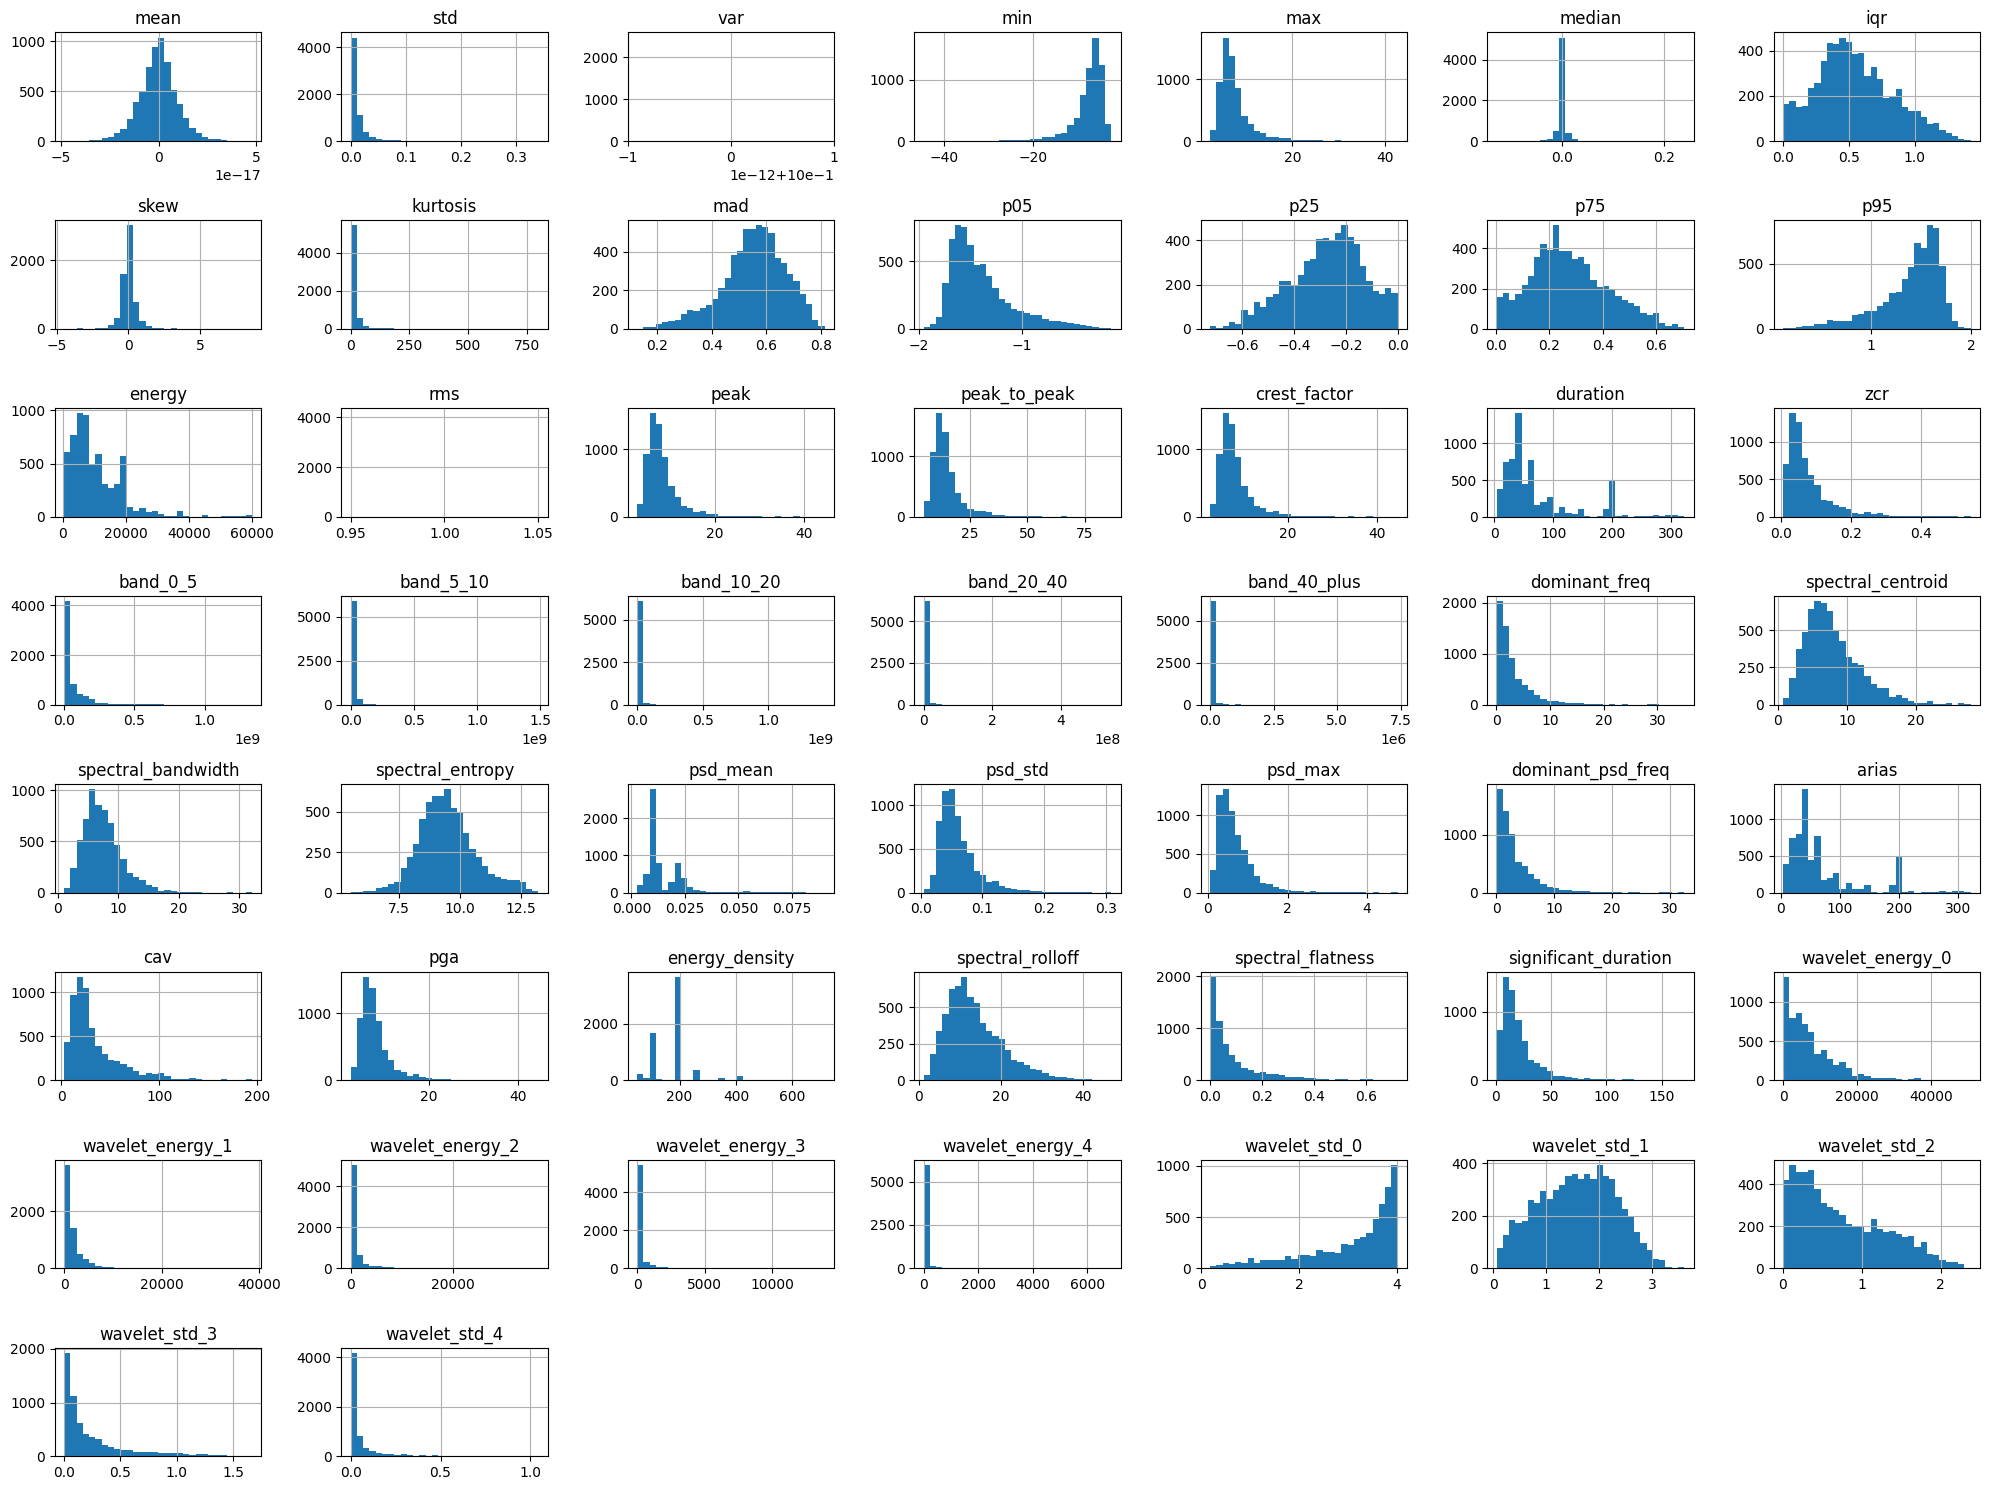

In [ ]:
train_feat[numeric_cols].hist(
    figsize=(20,15),
    bins=30
)

plt.tight_layout()
plt.show()

In [ ]:
features = [
    "energy",
    "rms",
    "duration",
    "dominant_freq",
    "spectral_entropy",
    "arias",
    "cav"
]

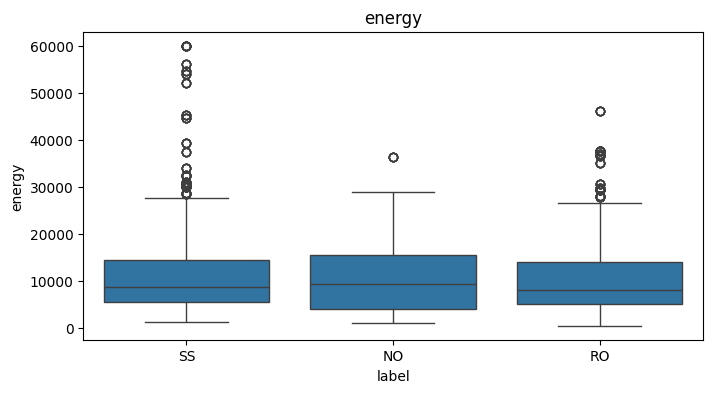

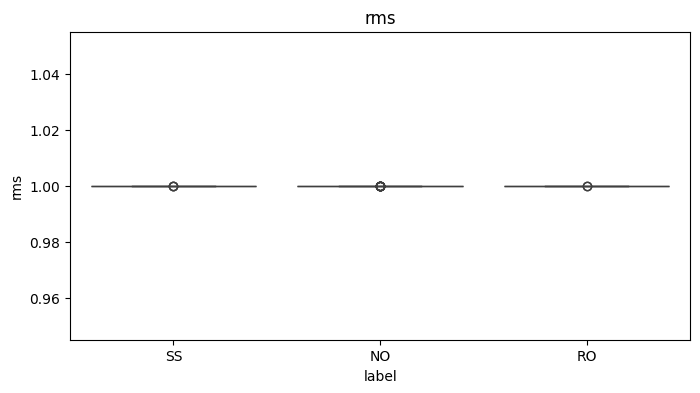

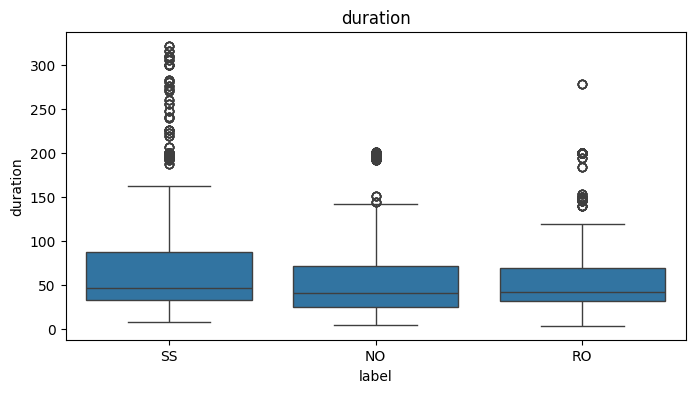

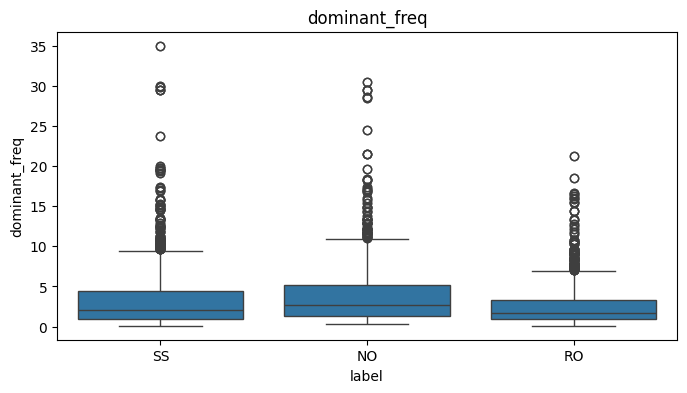

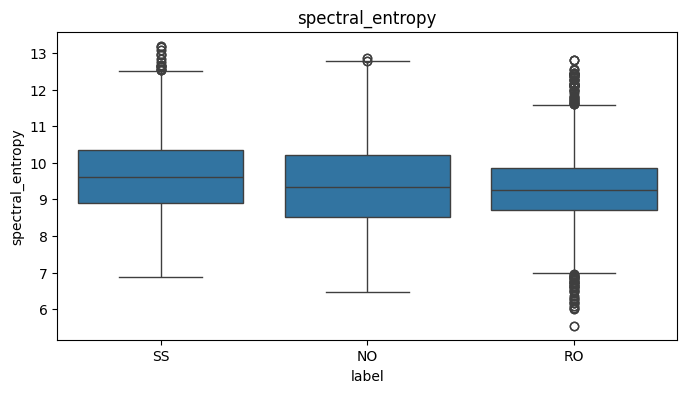

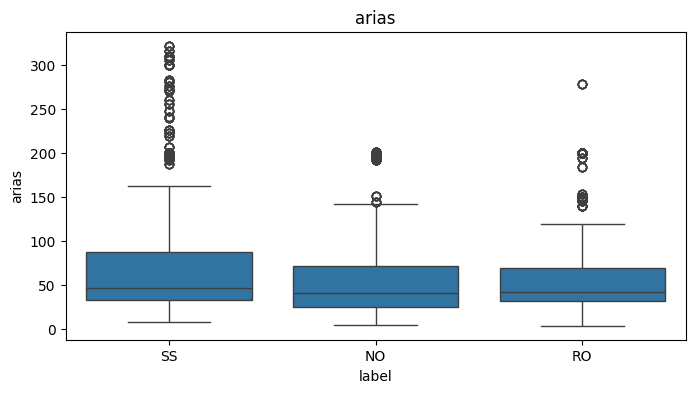

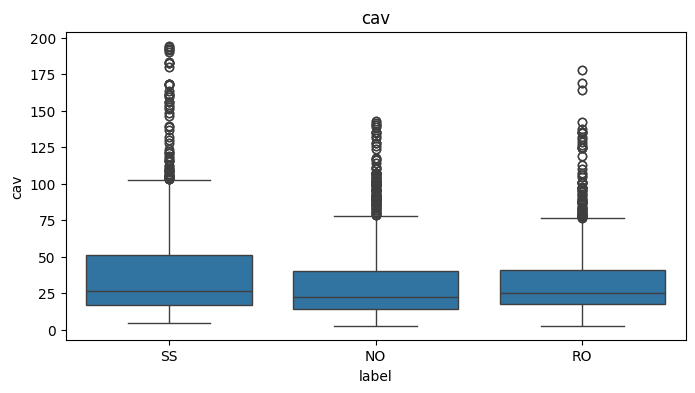

In [ ]:
for feat in features:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=train_feat,
        x="label",
        y=feat
    )

    plt.title(feat)

    plt.show()

In [ ]:
corr_df = train_feat.drop(
    columns=[
        "label",
        "event_id"
    ]
)

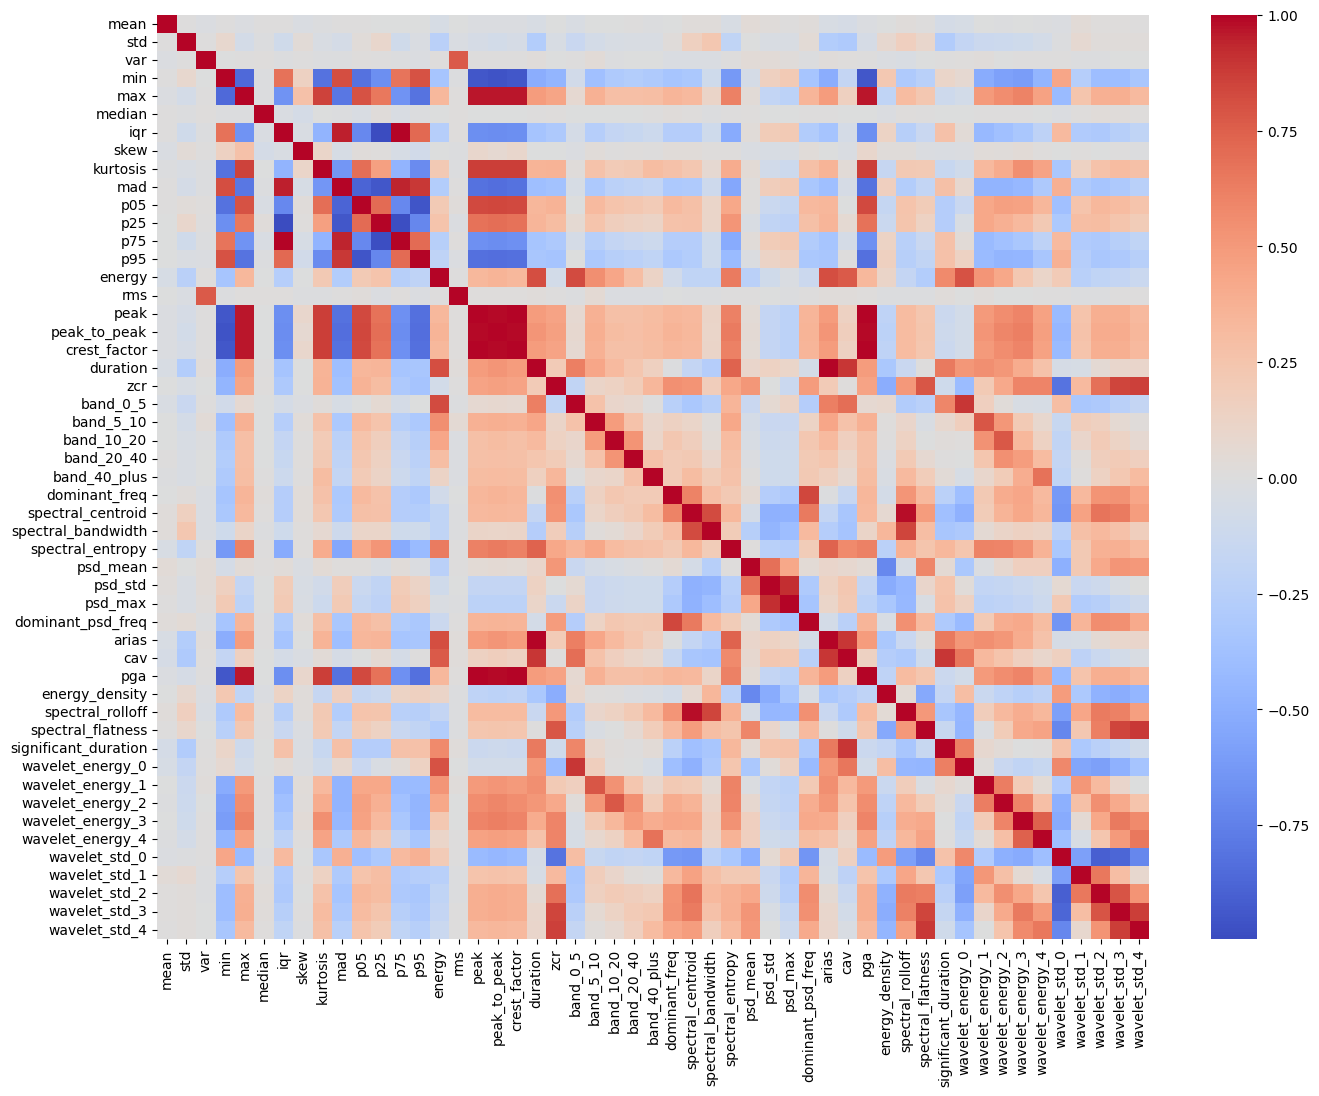

In [ ]:
plt.figure(figsize=(16,12))

sns.heatmap(
    corr_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.show()

In [ ]:
corr_matrix = corr_df.corr().abs()

In [ ]:
upper = corr_matrix.where(
    np.triu(
        np.ones(
            corr_matrix.shape
        ),
        k=1
    ).astype(bool)
)

In [ ]:
high_corr = [
    column
    for column in upper.columns
    if any(
        upper[column] > 0.95
    )
]

high_corr

['p25',
 'p75',
 'p95',
 'peak',
 'peak_to_peak',
 'crest_factor',
 'arias',
 'pga',
 'spectral_rolloff']

## Dataset Final

In [ ]:
cols_to_drop = [

    # percentiles redundantes
    "p25",
    "p75",
    "p95",

    # energía redundante
    "arias",

    # amplitud redundante
    "pga",

    # altamente correlacionadas
    "peak",
    "peak_to_peak",
    "crest_factor",

    "spectral_rolloff"

    # rms correlacionada con energy
    #"rms"
]

In [ ]:
train_model = train_feat.drop(
    columns=cols_to_drop
)

val_model = val_feat.drop(
    columns=cols_to_drop
)

test_model = test_feat.drop(
    columns=cols_to_drop
)

In [ ]:
X_train = train_model.drop(
    columns=["label","event_id"]
)

y_train = train_model["label"]

X_val = val_model.drop(
    columns=["label","event_id"]
)

y_val = val_model["label"]

X_test = test_model.drop(
    columns=["label","event_id"]
)

y_test = test_model["label"]

In [ ]:
print(X_train.shape)

(6329, 42)


## Escalado

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(
    X_train
)

X_val_sc = scaler.transform(
    X_val
)

X_test_sc = scaler.transform(
    X_test
)

## Models

###Logistic Regression

In [ ]:
gkf = GroupKFold(
    n_splits=5
)

param_grid = {

    "C": np.logspace(
        -4,
        4,
        20
    ),

    "penalty": [
        "l1",
        "l2"
    ],

    "solver": [
        "liblinear"
    ]
}

In [ ]:
lr = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

In [ ]:
grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=gkf,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_lr.fit(
    X_train_sc,
    y_train,
    groups=train_model["event_id"]
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


GridSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=5000, random_state=42),
             n_jobs=-1,
             param_grid={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                         'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
             return_train_score=True, scoring='f1_macro', verbose=2)

In [ ]:
print("Mejores parámetros:")
print(grid_lr.best_params_)
print("\nMejor F1 CV:")
print(grid_lr.best_score_)

Mejores parámetros:
{'C': np.float64(0.23357214690901212), 'penalty': 'l2', 'solver': 'liblinear'}

Mejor F1 CV:
0.48855009728798693


In [ ]:
best_lr = grid_lr.best_estimator_

In [ ]:
from sklearn.metrics import (
    classification_report,
    f1_score,
    balanced_accuracy_score
)

pred_val = best_lr.predict(
    X_val_sc
)

print(
    classification_report(
        y_val,
        pred_val
    )
)

print(
    "F1 Macro:",
    f1_score(
        y_val,
        pred_val,
        average="macro"
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_val,
        pred_val
    )
)

              precision    recall  f1-score   support

          NO       0.56      0.47      0.51       496
          RO       0.56      0.67      0.61       850
          SS       0.48      0.43      0.46       780

    accuracy                           0.54      2126
   macro avg       0.54      0.52      0.53      2126
weighted avg       0.53      0.54      0.53      2126

F1 Macro: 0.5269877978926558
Balanced Accuracy: 0.5243151851311244


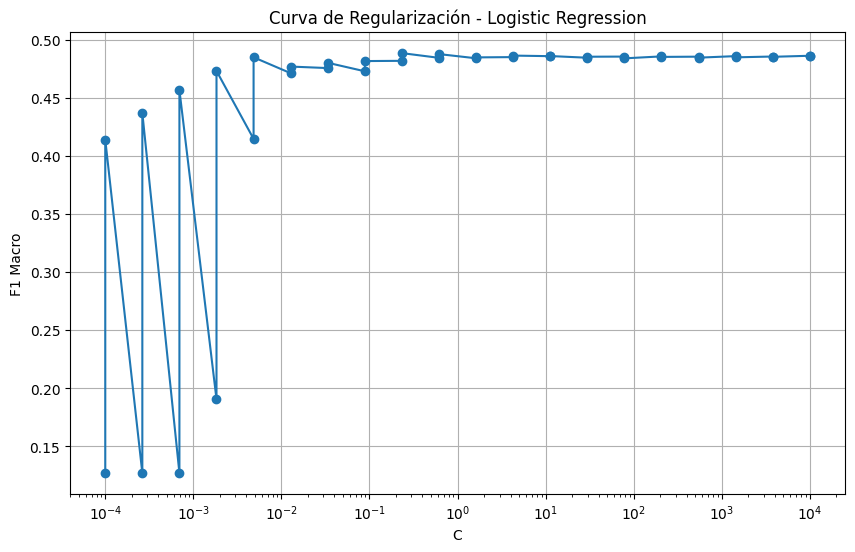

In [ ]:
results = pd.DataFrame(
    grid_lr.cv_results_
)

results["lambda"] = (
    1 /
    results["param_C"].astype(float)
)

plt.figure(figsize=(10,6))

plt.semilogx(

    results["param_C"],

    results["mean_test_score"],

    marker="o"
)

plt.xlabel("C")
plt.ylabel("F1 Macro")

plt.title(
    "Curva de Regularización - Logistic Regression"
)

plt.grid()

plt.show()

###Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold

gkf = GroupKFold(
    n_splits=5
)

param_grid = {

    "n_estimators": [
        300,
        500,
        800
    ],

    "max_depth": [
        10,
        20,
        30,
        None
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ],

    "max_features": [
        "sqrt",
        "log2"
    ]
}

In [ ]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [ ]:
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=gkf,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

In [ ]:
grid_rf.fit(
    X_train_sc,
    y_train,
    groups=train_model["event_id"]
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [300, 500, 800]},
             return_train_score=True, scoring='f1_macro', verbose=2)

In [ ]:
print("Best Params:")
print(grid_rf.best_params_)
print("\nBest CV F1:")
print(grid_rf.best_score_)

Best Params:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}

Best CV F1:
0.6920131406130946


In [ ]:
best_rf = grid_rf.best_estimator_

In [ ]:
from sklearn.metrics import (
    classification_report,
    f1_score,
    balanced_accuracy_score
)

pred_val = best_rf.predict(
    X_val
)

print(
    classification_report(
        y_val,
        pred_val
    )
)

print(
    "F1 Macro:",
    f1_score(
        y_val,
        pred_val,
        average="macro"
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_val,
        pred_val
    )
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


              precision    recall  f1-score   support

          NO       0.00      0.00      0.00       496
          RO       0.00      0.00      0.00       850
          SS       0.37      1.00      0.54       780

    accuracy                           0.37      2126
   macro avg       0.12      0.33      0.18      2126
weighted avg       0.13      0.37      0.20      2126

F1 Macro: 0.17894012388162425
Balanced Accuracy: 0.3333333333333333


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
imp = pd.DataFrame({

    "feature": X_train.columns,

    "importance":
        best_rf.feature_importances_

})

In [ ]:
imp = imp.sort_values(
    "importance",
    ascending=False
)

imp.head(15)

,feature,importance
1,std,0.080863
13,duration,0.054579
24,psd_mean,0.051811
11,energy,0.048411
14,zcr,0.036228
29,energy_density,0.031613
32,wavelet_energy_0,0.031403
28,cav,0.030672
30,spectral_flatness,0.028176
15,band_0_5,0.026932


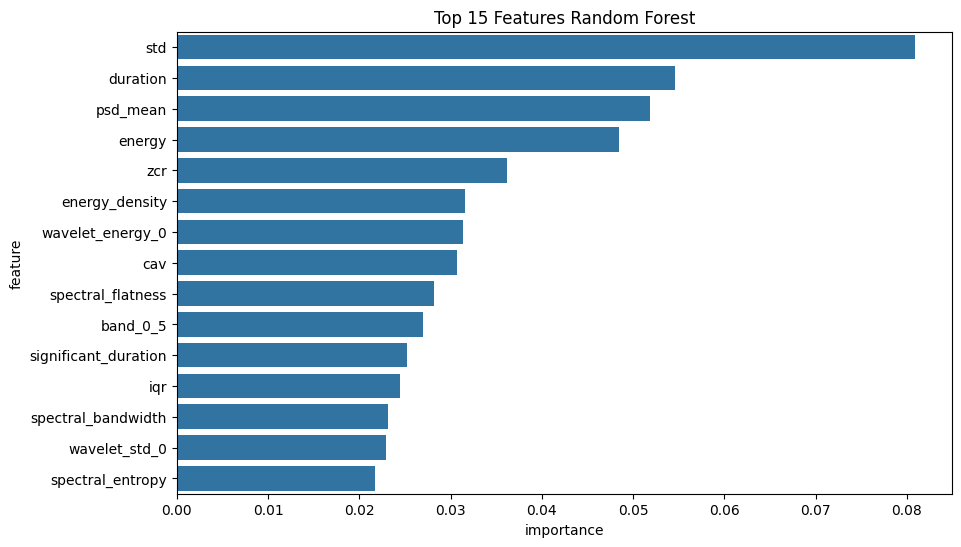

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=imp.head(15),
    x="importance",
    y="feature"
)

plt.title(
    "Top 15 Features Random Forest"
)

plt.show()

###XGBoost

In [ ]:
!pip install xgboost -q

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)

y_val_enc = le.transform(y_val)

y_test_enc = le.transform(y_test)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GroupKFold
from xgboost import XGBClassifier
import numpy as np

gkf = GroupKFold(
    n_splits=5
)

param_dist = {

    "n_estimators": [
        300,
        500,
        800,
        1200
    ],

    "max_depth": [
        3,
        4,
        5,
        6,
        7,
        8
    ],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],

    "subsample": [
        0.6,
        0.8,
        1.0
    ],

    "colsample_bytree": [
        0.6,
        0.8,
        1.0
    ],

    "min_child_weight": [
        1,
        3,
        5
    ],

    "gamma": [
        0,
        0.1,
        0.3,
        0.5
    ]
}

In [ ]:
xgb = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

In [ ]:
search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1_macro",
    cv=gkf,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

In [ ]:
search_xgb.fit(
    X_train,
    y_train_enc,
    groups=train_model["event_id"]
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,...
                                           n_estimators=None, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 7, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [300, 500, 800, 1200],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, return_train_score=True, scoring='f1_macro',
                   verbose=2)

In [ ]:
print(search_xgb.best_params_)
print(search_xgb.best_score_)

{'subsample': 0.8, 'n_estimators': 1200, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.8}
0.7099369047164963


In [ ]:
best_xgb = search_xgb.best_estimator_

In [ ]:
pred_val = best_xgb.predict(X_val)

In [ ]:
pred_val_labels = (
    le.inverse_transform(
        pred_val
    )
)

In [ ]:
from sklearn.metrics import (
    classification_report,
    f1_score,
    balanced_accuracy_score
)

print(
    classification_report(
        y_val,
        pred_val_labels
    )
)

print(
    "F1 Macro:",
    f1_score(
        y_val,
        pred_val_labels,
        average="macro"
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_val,
        pred_val_labels
    )
)

              precision    recall  f1-score   support

          NO       0.82      0.71      0.76       496
          RO       0.76      0.76      0.76       850
          SS       0.70      0.75      0.72       780

    accuracy                           0.75      2126
   macro avg       0.76      0.74      0.75      2126
weighted avg       0.75      0.75      0.75      2126

F1 Macro: 0.7482819031638285
Balanced Accuracy: 0.7419504857360645


In [ ]:
importance = pd.DataFrame({

    "feature":
        X_train.columns,

    "importance":
        best_xgb.feature_importances_

})

In [ ]:
importance = importance.sort_values(
    "importance",
    ascending=False
)

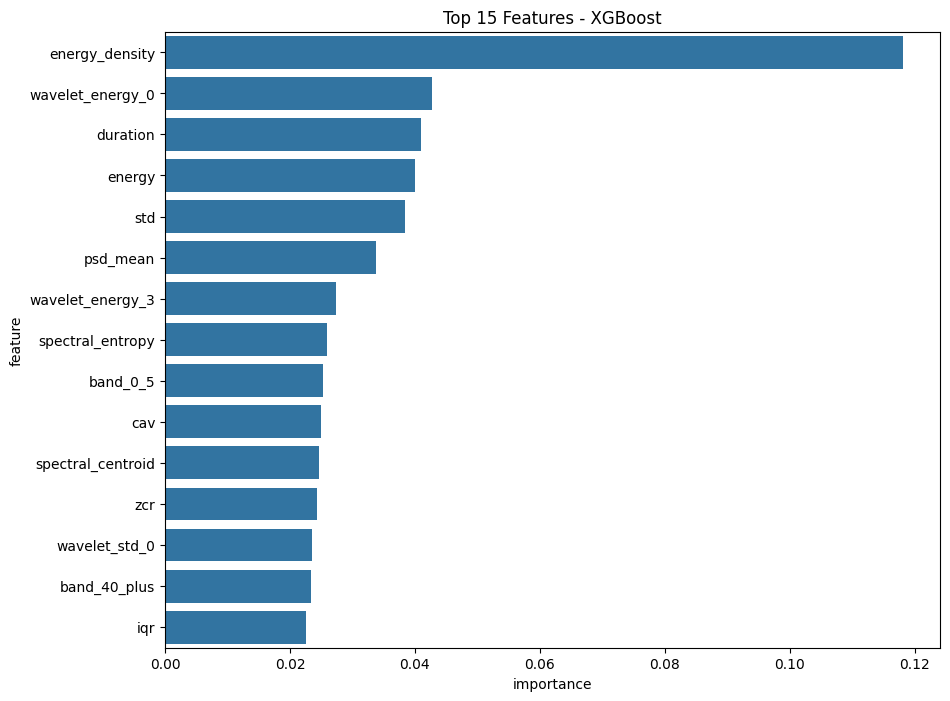

In [ ]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="importance",
    y="feature"
)

plt.title(
    "Top 15 Features - XGBoost"
)

plt.show()

### CatBoost

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 24.5 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(
    n_splits=5
)

param_dist = {

    "depth": [
        3,
        4,
        5,
        6
    ],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.07
    ],

    "iterations": [
        500,
        1000,
        1500,
        2000
    ],

    "l2_leaf_reg": [
        1,
        3,
        5,
        7,
        10
    ],

    "bagging_temperature": [
        0,
        1,
        2,
        3
    ],

    "random_strength": [
        1,
        2,
        3,
        5
    ]
}

In [ ]:
cat_base = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    random_state=42,
    verbose=False
)

In [ ]:
search_cat = RandomizedSearchCV(
    estimator=cat_base,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1_macro",
    cv=gkf,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

In [ ]:
search_cat.fit(
    X_train,
    y_train,
    groups=train_feat["event_id"]
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=CatBoostClassifier(eval_metric='TotalF1', loss_function='MultiClass', random_state=42, verbose=False),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'bagging_temperature': [0, 1, 2, 3],
                                        'depth': [3, 4, 5, 6],
                                        'iterations': [500, 1000, 1500, 2000],
                                        'l2_leaf_reg': [1, 3, 5, 7, 10],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.07],
                                        'random_strength': [1, 2, 3, 5]},
                   random_state=42, scoring='f1_macro', verbose=2)

In [ ]:
print(search_cat.best_params_)
print(search_cat.best_score_)

{'random_strength': 1, 'learning_rate': 0.07, 'l2_leaf_reg': 7, 'iterations': 1500, 'depth': 5, 'bagging_temperature': 0}
0.7104906944232223


In [ ]:
best_cat = search_cat.best_estimator_

In [ ]:
pred_val = best_cat.predict(X_val)

from sklearn.metrics import (
    classification_report,
    f1_score,
    balanced_accuracy_score
)

print(
    classification_report(
        y_val,
        pred_val
    )
)

print(
    "F1 Macro:",
    f1_score(
        y_val,
        pred_val,
        average="macro"
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_val,
        pred_val
    )
)


              precision    recall  f1-score   support

          NO       0.79      0.75      0.77       496
          RO       0.76      0.78      0.77       850
          SS       0.72      0.72      0.72       780

    accuracy                           0.75      2126
   macro avg       0.76      0.75      0.75      2126
weighted avg       0.75      0.75      0.75      2126

F1 Macro: 0.7543243777286367
Balanced Accuracy: 0.751774761186526


In [ ]:
cv_results = pd.DataFrame(
    search_cat.cv_results_
)

cols = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "params"
]

top10 = cv_results[
    cols
].sort_values(
    "rank_test_score"
).head(10)

top10

,rank_test_score,mean_test_score,std_test_score,params
0,1,0.710491,0.033568,"{'random_strength': 1, 'learning_rate': 0.07, ..."
23,2,0.709308,0.040655,"{'random_strength': 5, 'learning_rate': 0.07, ..."
22,3,0.707989,0.035672,"{'random_strength': 3, 'learning_rate': 0.07, ..."
21,4,0.706162,0.038604,"{'random_strength': 3, 'learning_rate': 0.05, ..."
25,5,0.702189,0.033633,"{'random_strength': 5, 'learning_rate': 0.07, ..."
31,6,0.700494,0.036291,"{'random_strength': 5, 'learning_rate': 0.05, ..."
1,7,0.697472,0.041640,"{'random_strength': 1, 'learning_rate': 0.07, ..."
26,8,0.696982,0.042237,"{'random_strength': 3, 'learning_rate': 0.07, ..."
11,9,0.688214,0.044128,"{'random_strength': 5, 'learning_rate': 0.03, ..."
27,10,0.687853,0.043239,"{'random_strength': 2, 'learning_rate': 0.07, ..."


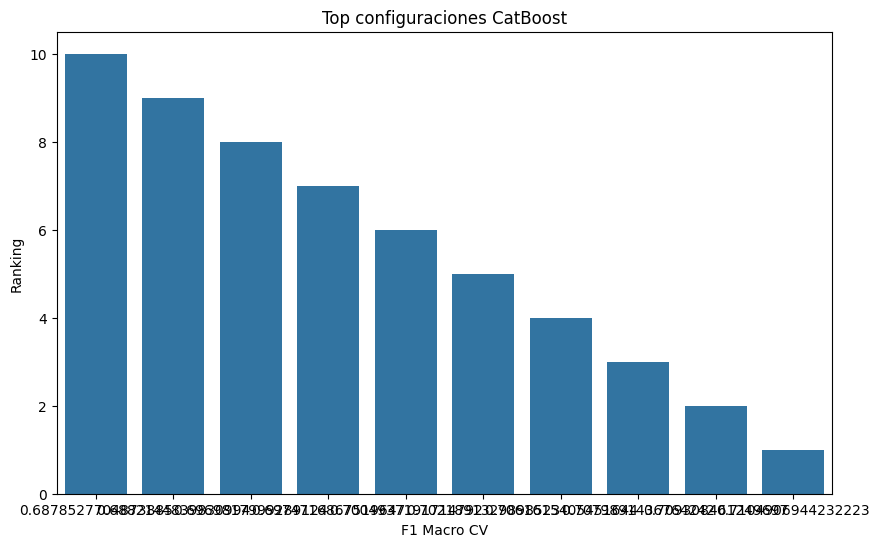

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top10["mean_test_score"],
    y=top10["rank_test_score"]
)

plt.xlabel("F1 Macro CV")
plt.ylabel("Ranking")

plt.title(
    "Top configuraciones CatBoost"
)

plt.show()

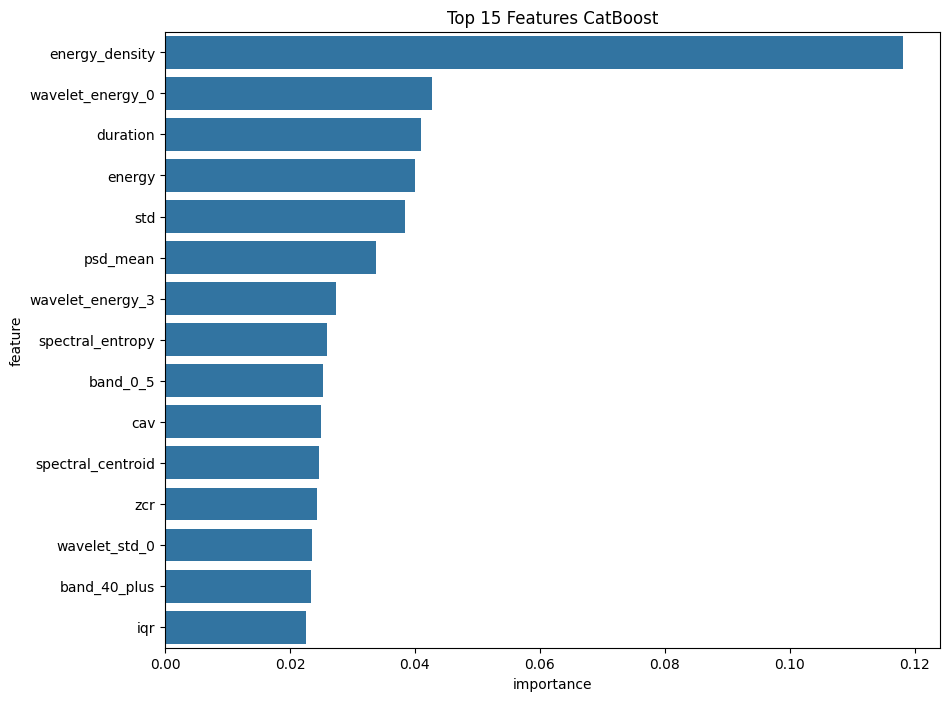

In [ ]:

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="importance",
    y="feature"
)

plt.title(
    "Top 15 Features CatBoost"
)

plt.show()

### Cross_val_score

In [ ]:
from sklearn.model_selection import cross_val_score
import pandas as pd

def evaluate_model_cv(model, X, y, groups, cv):

    metrics = {
        "Accuracy": "accuracy",
        "Balanced Accuracy": "balanced_accuracy",
        "Precision Macro": "precision_macro",
        "Recall Macro": "recall_macro",
        "F1 Macro": "f1_macro"
    }

    results = []

    for metric_name, scoring in metrics.items():

        scores = cross_val_score(
            model,
            X,
            y,
            groups=groups,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        results.append({
            "Metric": metric_name,
            "Mean": scores.mean(),
            "Std": scores.std()
        })

    return pd.DataFrame(results)

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.model_selection import GroupShuffleSplit

gkf = GroupShuffleSplit(
    n_splits=15,
    test_size=0.2,
    random_state=42
)

#gkf = GroupKFold(
 #   n_splits=5
#)

groups = train_feat["event_id"]

In [ ]:
lr_results = evaluate_model_cv(
    best_lr,
    X_train_sc,
    y_train,
    groups,
    gkf
)

print("LOGISTIC")
display(lr_results)

LOGISTIC


,Metric,Mean,Std
0,Accuracy,0.502240,0.023576
1,Balanced Accuracy,0.492150,0.022204
2,Precision Macro,0.497255,0.021151
3,Recall Macro,0.492150,0.022204
4,F1 Macro,0.489541,0.021158


In [ ]:
rf_results = evaluate_model_cv(
    best_rf,
    X_train,
    y_train,
    groups,
    gkf
)

print("RANDOM FOREST")
display(rf_results)

RANDOM FOREST


,Metric,Mean,Std
0,Accuracy,0.669010,0.035352
1,Balanced Accuracy,0.664036,0.038317
2,Precision Macro,0.685463,0.036579
3,Recall Macro,0.664036,0.038317
4,F1 Macro,0.671456,0.037546


In [ ]:
xgb_results = evaluate_model_cv(
    best_xgb,
    X_train,
    y_train_enc,
    groups,
    gkf
)

print("XGBOOST")
display(xgb_results)

XGBOOST


,Metric,Mean,Std
0,Accuracy,0.698638,0.029647
1,Balanced Accuracy,0.696675,0.033893
2,Precision Macro,0.709630,0.030845
3,Recall Macro,0.696675,0.033893
4,F1 Macro,0.701375,0.032355


In [ ]:
cat_results = evaluate_model_cv(
    best_cat,
    X_train,
    y_train,
    groups,
    gkf
)

print("CATBOOST")
display(cat_results)

CATBOOST


,Metric,Mean,Std
0,Accuracy,0.691457,0.031687
1,Balanced Accuracy,0.691059,0.035650
2,Precision Macro,0.700687,0.034138
3,Recall Macro,0.691059,0.035650
4,F1 Macro,0.694377,0.034964


In [ ]:
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "CatBoost"
    ],

    "Accuracy": [

        lr_results.loc[
            lr_results["Metric"]=="Accuracy",
            "Mean"
        ].values[0],

        rf_results.loc[
            rf_results["Metric"]=="Accuracy",
            "Mean"
        ].values[0],

        xgb_results.loc[
            xgb_results["Metric"]=="Accuracy",
            "Mean"
        ].values[0],

        cat_results.loc[
            cat_results["Metric"]=="Accuracy",
            "Mean"
        ].values[0]
    ],

    "Balanced Accuracy": [

        lr_results.loc[
            lr_results["Metric"]=="Balanced Accuracy",
            "Mean"
        ].values[0],

        rf_results.loc[
            rf_results["Metric"]=="Balanced Accuracy",
            "Mean"
        ].values[0],

        xgb_results.loc[
            xgb_results["Metric"]=="Balanced Accuracy",
            "Mean"
        ].values[0],

        cat_results.loc[
            cat_results["Metric"]=="Balanced Accuracy",
            "Mean"
        ].values[0]
    ],

    "Precision Macro": [

        lr_results.loc[
            lr_results["Metric"]=="Precision Macro",
            "Mean"
        ].values[0],

        rf_results.loc[
            rf_results["Metric"]=="Precision Macro",
            "Mean"
        ].values[0],

        xgb_results.loc[
            xgb_results["Metric"]=="Precision Macro",
            "Mean"
        ].values[0],

        cat_results.loc[
            cat_results["Metric"]=="Precision Macro",
            "Mean"
        ].values[0]
    ],

    "Recall Macro": [

        lr_results.loc[
            lr_results["Metric"]=="Recall Macro",
            "Mean"
        ].values[0],

        rf_results.loc[
            rf_results["Metric"]=="Recall Macro",
            "Mean"
        ].values[0],

        xgb_results.loc[
            xgb_results["Metric"]=="Recall Macro",
            "Mean"
        ].values[0],

        cat_results.loc[
            cat_results["Metric"]=="Recall Macro",
            "Mean"
        ].values[0]
    ],

    "F1 Macro": [

        lr_results.loc[
            lr_results["Metric"]=="F1 Macro",
            "Mean"
        ].values[0],

        rf_results.loc[
            rf_results["Metric"]=="F1 Macro",
            "Mean"
        ].values[0],

        xgb_results.loc[
            xgb_results["Metric"]=="F1 Macro",
            "Mean"
        ].values[0],

        cat_results.loc[
            cat_results["Metric"]=="F1 Macro",
            "Mean"
        ].values[0]
    ]
})

comparison = comparison.sort_values(
    "F1 Macro",
    ascending=False
)

comparison

,Model,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro
2,XGBoost,0.698638,0.696675,0.709630,0.696675,0.701375
3,CatBoost,0.691457,0.691059,0.700687,0.691059,0.694377
1,Random Forest,0.669010,0.664036,0.685463,0.664036,0.671456
0,Logistic Regression,0.502240,0.492150,0.497255,0.492150,0.489541


###Test Hipotesis

In [ ]:
lr_scores = cross_val_score(
    best_lr,
    X_train_sc,
    y_train,
    groups=groups,
    cv=gkf,
    scoring="f1_macro",
    n_jobs=-1
)

print(lr_scores)

[0.46606504 0.47775927 0.47270579 0.47115675 0.45786327 0.4919116
 0.46026544 0.52048063 0.51717915 0.51452861 0.47632114 0.49545241
 0.50260417 0.5060626  0.51275437]


In [ ]:
rf_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    groups=groups,
    cv=gkf,
    scoring="f1_macro",
    n_jobs=-1
)

print(rf_scores)

[0.66607893 0.67181827 0.68206369 0.64440545 0.61798566 0.6772752
 0.62223258 0.75173401 0.69419027 0.64459169 0.71119077 0.60690096
 0.69584686 0.69625382 0.68927292]


In [ ]:
xgb_scores = cross_val_score(
    best_xgb,
    X_train,
    y_train_enc,
    groups=groups,
    cv=gkf,
    scoring="f1_macro",
    n_jobs=-1
)

print(xgb_scores)

[0.70767918 0.69714352 0.72591335 0.71185668 0.6581974  0.71635084
 0.63476422 0.76572739 0.68425134 0.69121485 0.735822   0.65385563
 0.71780977 0.71170126 0.70834248]


In [ ]:
cat_scores = cross_val_score(
    best_cat,
    X_train,
    y_train,
    groups=groups,
    cv=gkf,
    scoring="f1_macro",
    n_jobs=-1
)

print(cat_scores)

[0.70563193 0.68318111 0.71827202 0.69029193 0.67108035 0.69045894
 0.6249542  0.76547951 0.68014298 0.65470054 0.74034177 0.65910838
 0.7379802  0.6942215  0.69981487]


#### Mejora % respecto a lr

In [ ]:
baseline_f1 = comparison.loc[
    comparison["Model"]=="Logistic Regression",
    "F1 Macro"
].values[0]

comparison["Improvement_vs_LR_%"] = (
    (
        comparison["F1 Macro"] - baseline_f1
    )
    /
    baseline_f1
) * 100

comparison

,Model,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,Improvement_vs_LR_%
2,XGBoost,0.698638,0.696675,0.709630,0.696675,0.701375,43.272123
3,CatBoost,0.691457,0.691059,0.700687,0.691059,0.694377,41.842624
1,Random Forest,0.669010,0.664036,0.685463,0.664036,0.671456,37.160423
0,Logistic Regression,0.502240,0.492150,0.497255,0.492150,0.489541,0.000000


#### Friedman Test

In [ ]:
from scipy.stats import friedmanchisquare

stat, p = friedmanchisquare(
    lr_scores,
    rf_scores,
    xgb_scores,
    cat_scores
)

print("Friedman Statistic:", stat)
print("p-value:", p)

Friedman Statistic: 36.920000000000016
p-value: 4.784245104165892e-08


In [ ]:
alpha = 0.05

if p < alpha:
    print(
        "Existen diferencias significativas entre los modelos"
    )
else:
    print(
        "No existen diferencias significativas"
    )

Existen diferencias significativas entre los modelos


#### Wilcoxon

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from itertools import combinations

In [ ]:
def wilcoxon_seguro(scores_a, scores_b):
    scores_a = np.array(scores_a)
    scores_b = np.array(scores_b)

    diferencias = scores_a - scores_b

    # Caso crítico: todos los folds tienen exactamente la misma diferencia = 0
    if np.allclose(diferencias, 0):
        return 0, 1.0   # No hay diferencia estadística

    stat, p_value = wilcoxon(
        scores_a,
        scores_b,
        zero_method="zsplit",   # Maneja empates/diferencias cero
        alternative="two-sided"
    )

    return stat, p_value

In [ ]:
scores_modelos = {
    "Logistic Regression": lr_scores,
    "Random Forest": rf_scores,
    "XG Boost": xgb_scores,
    "CatBoost": cat_scores
}

In [ ]:
resultados_wilcoxon = []

for modelo_a, modelo_b in combinations(scores_modelos.keys(), 2):

    scores_a = scores_modelos[modelo_a]
    scores_b = scores_modelos[modelo_b]

    stat, p_value = wilcoxon_seguro(scores_a, scores_b)

    mean_a = np.mean(scores_a)
    mean_b = np.mean(scores_b)

    diferencia = mean_a - mean_b

    if diferencia > 0:
        mejor_modelo = modelo_a
    elif diferencia < 0:
        mejor_modelo = modelo_b
    else:
        mejor_modelo = "Empate"

    resultados_wilcoxon.append({
        "Modelo A": modelo_a,
        "Modelo B": modelo_b,
        "Media A": mean_a,
        "Media B": mean_b,
        "Diferencia A-B": diferencia,
        "Mejor modelo": mejor_modelo,
        "Wilcoxon stat": stat,
        "p-value": p_value,
        "Significativo": "Sí" if p_value < 0.0083 else "No"
    })

tabla_wilcoxon = pd.DataFrame(resultados_wilcoxon)

tabla_wilcoxon

,Modelo A,Modelo B,Media A,Media B,Diferencia A-B,Mejor modelo,Wilcoxon stat,p-value,Significativo
0,Logistic Regression,Random Forest,0.489541,0.671456,-0.181915,Random Forest,0.0,0.000061,Sí
1,Logistic Regression,XG Boost,0.489541,0.701375,-0.211835,XG Boost,0.0,0.000061,Sí
2,Logistic Regression,CatBoost,0.489541,0.694377,-0.204837,CatBoost,0.0,0.000061,Sí
3,Random Forest,XG Boost,0.671456,0.701375,-0.029919,XG Boost,1.0,0.000122,Sí
4,Random Forest,CatBoost,0.671456,0.694377,-0.022921,CatBoost,9.0,0.002014,Sí
5,XG Boost,CatBoost,0.701375,0.694377,0.006998,XG Boost,30.0,0.094604,No


In [ ]:
tabla_wilcoxon.sort_values("p-value")

,Modelo A,Modelo B,Media A,Media B,Diferencia A-B,Mejor modelo,Wilcoxon stat,p-value,Significativo
0,Logistic Regression,Random Forest,0.489541,0.671456,-0.181915,Random Forest,0.0,0.000061,Sí
1,Logistic Regression,XG Boost,0.489541,0.701375,-0.211835,XG Boost,0.0,0.000061,Sí
2,Logistic Regression,CatBoost,0.489541,0.694377,-0.204837,CatBoost,0.0,0.000061,Sí
3,Random Forest,XG Boost,0.671456,0.701375,-0.029919,XG Boost,1.0,0.000122,Sí
4,Random Forest,CatBoost,0.671456,0.694377,-0.022921,CatBoost,9.0,0.002014,Sí
5,XG Boost,CatBoost,0.701375,0.694377,0.006998,XG Boost,30.0,0.094604,No


In [ ]:
tabla_wilcoxon.round({
    "Media A": 4,
    "Media B": 4,
    "Diferencia A-B": 4,
    "Wilcoxon stat": 4,
    "p-value": 6
})

,Modelo A,Modelo B,Media A,Media B,Diferencia A-B,Mejor modelo,Wilcoxon stat,p-value,Significativo
0,Logistic Regression,Random Forest,0.4895,0.6715,-0.1819,Random Forest,0.0,0.000061,Sí
1,Logistic Regression,XG Boost,0.4895,0.7014,-0.2118,XG Boost,0.0,0.000061,Sí
2,Logistic Regression,CatBoost,0.4895,0.6944,-0.2048,CatBoost,0.0,0.000061,Sí
3,Random Forest,XG Boost,0.6715,0.7014,-0.0299,XG Boost,1.0,0.000122,Sí
4,Random Forest,CatBoost,0.6715,0.6944,-0.0229,CatBoost,9.0,0.002014,Sí
5,XG Boost,CatBoost,0.7014,0.6944,0.0070,XG Boost,30.0,0.094604,No


In [ ]:
for modelo in ["Random Forest", "XG Boost", "CatBoost"]:

    diferencias = np.array(scores_modelos["Logistic Regression"]) - np.array(scores_modelos[modelo])

    print("\nLogistic Regression vs", modelo)
    print("Diferencias LR - Modelo:")
    print(diferencias)
    print("LR gana en folds:", np.sum(diferencias > 0))
    print("Modelo gana en folds:", np.sum(diferencias < 0))
    print("Empates:", np.sum(diferencias == 0))


Logistic Regression vs Random Forest
Diferencias LR - Modelo:
[-0.20001389 -0.194059   -0.2093579  -0.17324871 -0.16012239 -0.1853636
 -0.16196714 -0.23125338 -0.17701111 -0.13006308 -0.23486963 -0.11144855
 -0.19324269 -0.19019122 -0.17651855]
LR gana en folds: 0
Modelo gana en folds: 15
Empates: 0

Logistic Regression vs XG Boost
Diferencias LR - Modelo:
[-0.24161414 -0.21938425 -0.25320756 -0.24069993 -0.20033413 -0.22443924
 -0.17449878 -0.24524676 -0.16707219 -0.17668624 -0.25950086 -0.15840322
 -0.21520559 -0.20563866 -0.19558811]
LR gana en folds: 0
Modelo gana en folds: 15
Empates: 0

Logistic Regression vs CatBoost
Diferencias LR - Modelo:
[-0.23956689 -0.20542184 -0.24556623 -0.21913519 -0.21321708 -0.19854735
 -0.16468877 -0.24499888 -0.16296383 -0.14017193 -0.26402064 -0.16365597
 -0.23537603 -0.1881589  -0.18706049]
LR gana en folds: 0
Modelo gana en folds: 15
Empates: 0


## Train Final CatBoost

In [ ]:
train_final = pd.concat(
    [train_feat, val_feat],
    ignore_index=True
)

In [ ]:
X_train_final = train_final.drop(
    columns=["label","event_id"]
)

y_train_final = train_final["label"]

X_test_final = test_feat.drop(
    columns=["label","event_id"]
)

y_test_final = test_feat["label"]

In [ ]:
print(X_train_final.shape)
print(y_train_final.shape)
print(X_test_final.shape)
print(y_test_final.shape)


(8455, 51)
(8455,)
(2132, 51)
(2132,)


In [ ]:
from catboost import CatBoostClassifier

cat_final = best_cat


In [ ]:
cat_final.fit(
    X_train_final,
    y_train_final,
    eval_set=(X_test_final, y_test_final),
    use_best_model=True,
    early_stopping_rounds=200
)

CatBoostClassifier(bagging_temperature=0, depth=5, eval_metric='TotalF1', iterations=1500, l2_leaf_reg=7, learning_rate=0.07, loss_function='MultiClass', random_state=42, random_strength=1, verbose=False)

In [ ]:
pred_test = cat_final.predict(
    X_test_final
)

pred_test = pred_test.ravel()

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    balanced_accuracy_score
)

print(
    classification_report(
        y_test_final,
        pred_test
    )
)

print(
    "F1 Macro:",
    f1_score(
        y_test_final,
        pred_test,
        average="macro"
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_test_final,
        pred_test
    )
)

              precision    recall  f1-score   support

          NO       0.77      0.72      0.74       500
          RO       0.75      0.77      0.76       840
          SS       0.69      0.70      0.69       792

    accuracy                           0.73      2132
   macro avg       0.74      0.73      0.73      2132
weighted avg       0.73      0.73      0.73      2132

F1 Macro: 0.7322978421376591
Balanced Accuracy: 0.7289745069745069


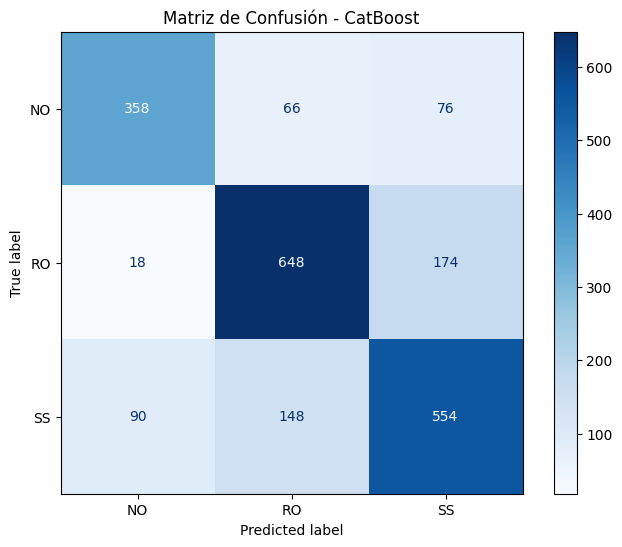

In [ ]:
cm = confusion_matrix(
    y_test_final,
    pred_test
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cat_final.classes_
)

fig, ax = plt.subplots(
    figsize=(8,6)
)

disp.plot(
    cmap="Blues",
    ax=ax
)

plt.title(
    "Matriz de Confusión - CatBoost"
)

plt.show()

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import learning_curve

groups = train_final["event_id"]

cv = GroupKFold(
    n_splits=5
)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=CatBoostClassifier(
      iterations=1000,
      depth=4,
      learning_rate=0.03,
      loss_function="MultiClass",
      eval_metric="TotalF1",
      random_state=42,
      verbose=100
    ),
    X=X_train_final,
    y=y_train_final,
    groups=groups,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    train_sizes=np.linspace(
        0.1,
        1.0,
        10
    )
)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", line 5547, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", line 2716, in _fit


In [ ]:
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

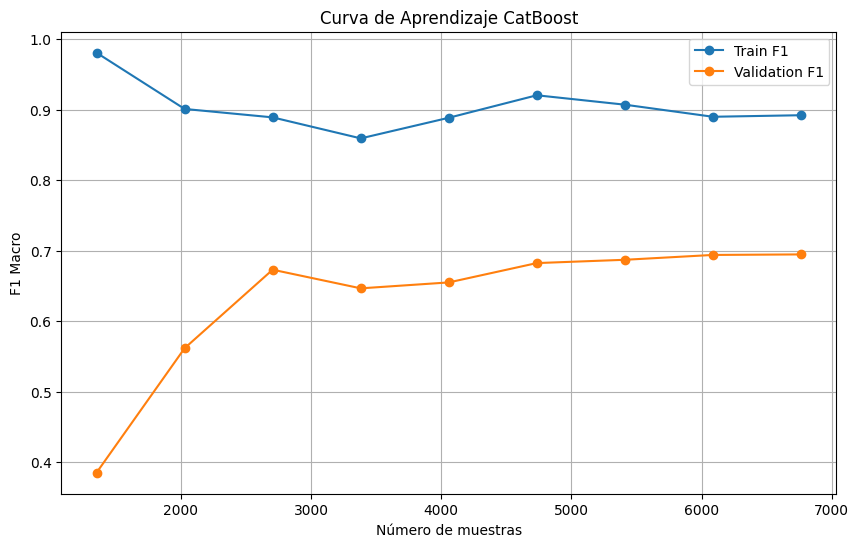

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Train F1"
)

plt.plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation F1"
)

plt.xlabel(
    "Número de muestras"
)

plt.ylabel(
    "F1 Macro"
)

plt.title(
    "Curva de Aprendizaje CatBoost"
)

plt.legend()

plt.grid()

plt.show()

## Train Final XGBoost

In [ ]:
train_final = pd.concat(
    [train_feat, val_feat],
    ignore_index=True
)

In [ ]:
X_train_final = train_final.drop(
    columns=["label","event_id"]
)

y_train_final = train_final["label"]

X_test_final = test_feat.drop(
    columns=["label","event_id"]
)

y_test_final = test_feat["label"]

In [ ]:
print(X_train_final.shape)
print(y_train_final.shape)
print(X_test_final.shape)
print(y_test_final.shape)


(8455, 51)
(8455,)
(2132, 51)
(2132,)


In [ ]:
le = LabelEncoder()

y_train_final_enc = le.fit_transform(y_train_final)

y_test_final_enc = le.transform(y_test_final)

In [ ]:
XGB_final = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    subsample=0.8,
    n_estimators=1200,
    min_child_weight=5,
    max_depth=7,
    learning_rate=0.03,
    gamma=0.3,
    colsample_bytree=0.8
)

In [ ]:
XGB_final.fit(
    X_train_final,
    y_train_final_enc
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.3,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
pred_test = XGB_final.predict(
    X_test_final
)

pred_test = pred_test.ravel()

In [ ]:
pred_test_labels = (
    le.inverse_transform(
        pred_test
    )
)

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    balanced_accuracy_score
)

print(
    classification_report(
        y_test_final,
        pred_test_labels
    )
)

print(
    "F1 Macro:",
    f1_score(
        y_test_final,
        pred_test_labels,
        average="macro"
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_test_final,
        pred_test_labels
    )
)

              precision    recall  f1-score   support

          NO       0.75      0.73      0.74       500
          RO       0.73      0.77      0.75       840
          SS       0.68      0.65      0.67       792

    accuracy                           0.72      2132
   macro avg       0.72      0.72      0.72      2132
weighted avg       0.72      0.72      0.72      2132

F1 Macro: 0.7173647270468356
Balanced Accuracy: 0.7162356902356902


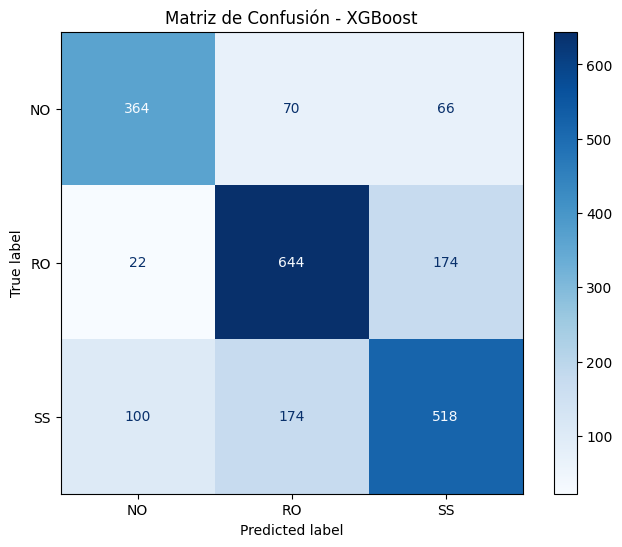

In [ ]:
cm = confusion_matrix(
    y_test_final,
    pred_test_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cat_final.classes_
)

fig, ax = plt.subplots(
    figsize=(8,6)
)

disp.plot(
    cmap="Blues",
    ax=ax
)

plt.title(
    "Matriz de Confusión - XGBoost"
)

plt.show()

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import learning_curve

groups = train_final["event_id"]

cv = GroupKFold(
    n_splits=5
)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
        subsample=0.8,
        n_estimators=700,
        min_child_weight=4,
        max_depth=15,
        learning_rate=0.03,
        gamma=0.7,
        colsample_bytree=0.8,
        reg_alpha=2,
        reg_lambda=10
    ),
    X=X_train_final,
    y=y_train_final_enc,
    groups=groups,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    train_sizes=np.linspace(
        0.1,
        1.0,
        10
    )
)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1761, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expe

In [ ]:
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

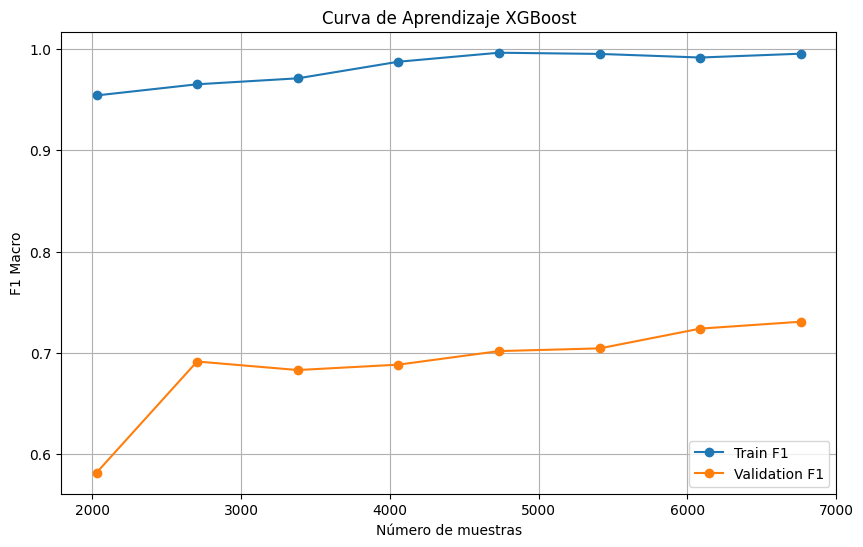

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Train F1"
)

plt.plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation F1"
)

plt.xlabel(
    "Número de muestras"
)

plt.ylabel(
    "F1 Macro"
)

plt.title(
    "Curva de Aprendizaje XGBoost"
)

plt.legend()

plt.grid()

plt.show()